In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting up visualization style
plt.style.use('ggplot')
sns.set_palette("pastel")


In [8]:
file_path = "US Superstore data.xls"

xls = pd.ExcelFile(file_path)
print(xls.sheet_names)

df = pd.read_excel(xls, sheet_name=xls.sheet_names[0])


df.info()
df.head()


['Orders']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Catego

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

duplicates = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicates)

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df.dtypes[['Order Date', 'Ship Date']]


Missing values per column:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Number of duplicate rows: 0


Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

Which states have the most sales?


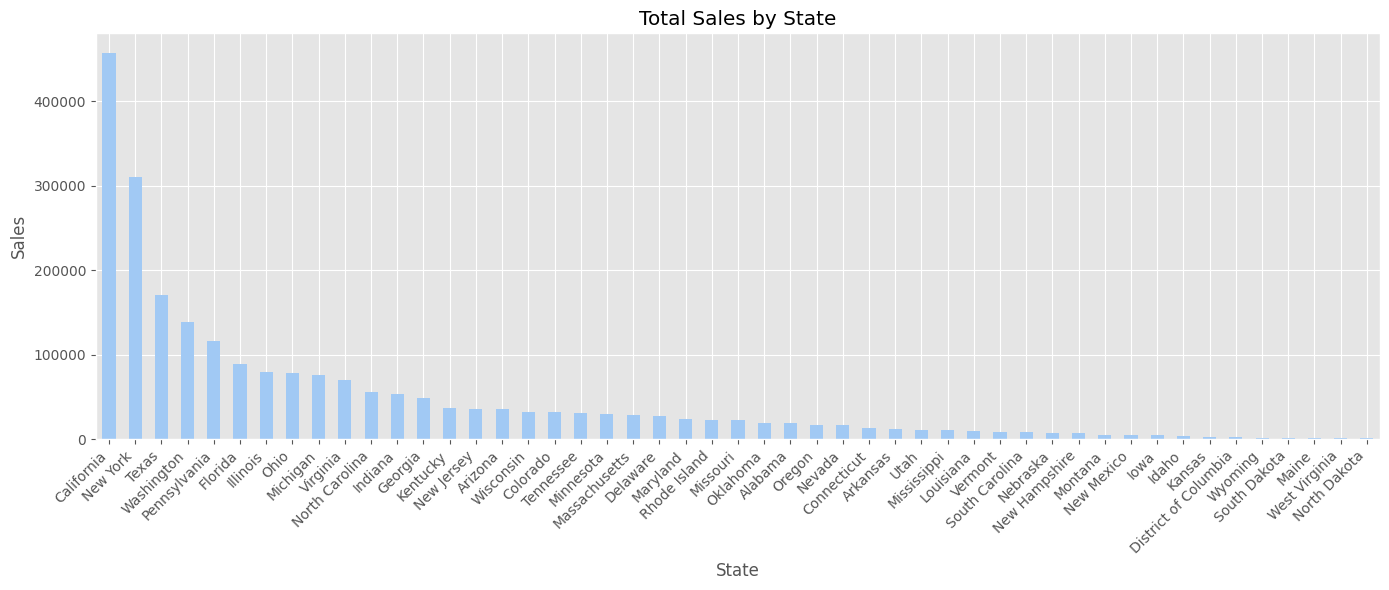

In [12]:
print("Which states have the most sales?")
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
state_sales.plot(kind='bar')
plt.title('Total Sales by State')
plt.ylabel('Sales')
plt.xlabel('State')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

What is the difference between New York and California in terms of sales and profit?


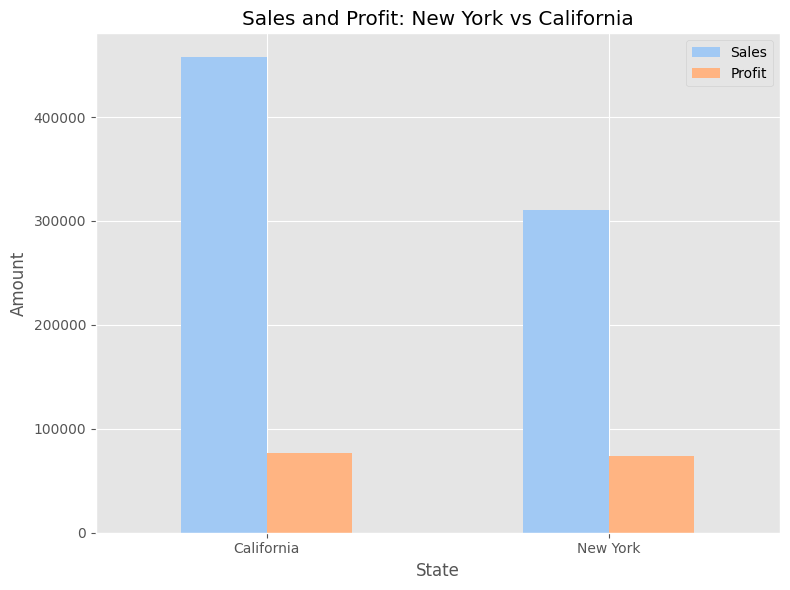


Total Sales and Profit:
California: Sales = $457,687.63, Profit = $76,381.39
New York: Sales = $310,876.27, Profit = $74,038.55

 Difference (California - New York):
Sales Difference: $146,811.36
Profit Difference: $2,342.84


In [ ]:
print("What is the difference between New York and California in terms of sales and profit?")
ny_ca = df[df['State'].isin(['New York', 'California'])]

ny_ca_summary = ny_ca.groupby('State')[['Sales', 'Profit']].sum()

ny_ca_summary.plot(kind='bar', figsize=(8, 6))
plt.title('Sales and Profit: New York vs California')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

ny_ca_summary

print("\nTotal Sales and Profit:")
for state in ny_ca_summary.index:
    sales = ny_ca_summary.loc[state, 'Sales']
    profit = ny_ca_summary.loc[state, 'Profit']
    print(f"{state}: Sales = ${sales:,.2f}, Profit = ${profit:,.2f}")


difference = ny_ca_summary.loc['California'] - ny_ca_summary.loc['New York']
print("\n Difference (California - New York):")
print(f"Sales Difference: ${difference['Sales']:,.2f}")
print(f"Profit Difference: ${difference['Profit']:,.2f}")

In [23]:
ny_customers = df[df['State'] == 'New York']

ny_customer_summary = ny_customers.groupby('Customer Name')[['Sales', 'Profit']].sum()
top_ny_customer = ny_customer_summary.sort_values(by='Profit', ascending=False).head(1)

print("Outstanding Customer in New York (by Profit):")
print(top_ny_customer)


Outstanding Customer in New York (by Profit):
                   Sales     Profit
Customer Name                      
Tom Ashbrook   13723.498  4599.2073


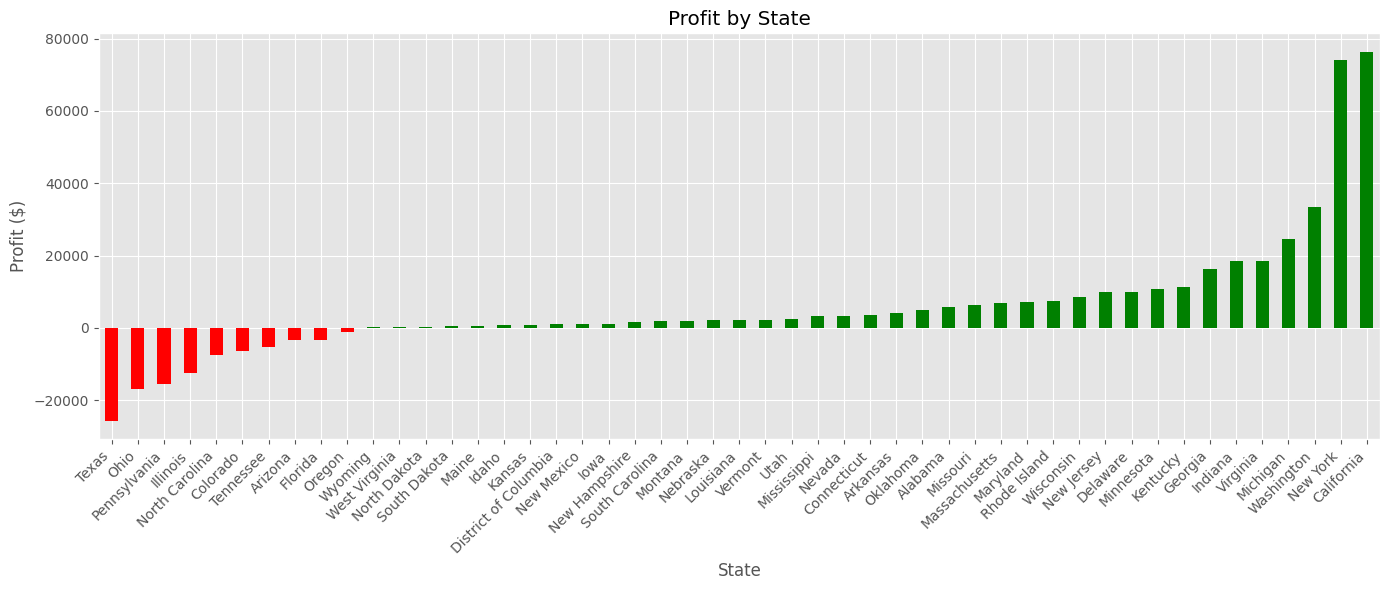


States with Negative Profit:
State
Texas            -25729.3563
Ohio             -16971.3766
Pennsylvania     -15559.9603
Illinois         -12607.8870
North Carolina    -7490.9122
Colorado          -6527.8579
Tennessee         -5341.6936
Arizona           -3427.9246
Florida           -3399.3017
Oregon            -1190.4705
Name: Profit, dtype: float64


In [ ]:
state_profit = df.groupby('State')['Profit'].sum().sort_values()

plt.figure(figsize=(14, 6))
state_profit.plot(kind='bar', color=['red' if val < 0 else 'green' for val in state_profit])
plt.title('Profit by State')
plt.ylabel('Profit ($)')
plt.xlabel('State')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

loss_states = state_profit[state_profit < 0]
print("\nStates with Negative Profit:")
print(loss_states)


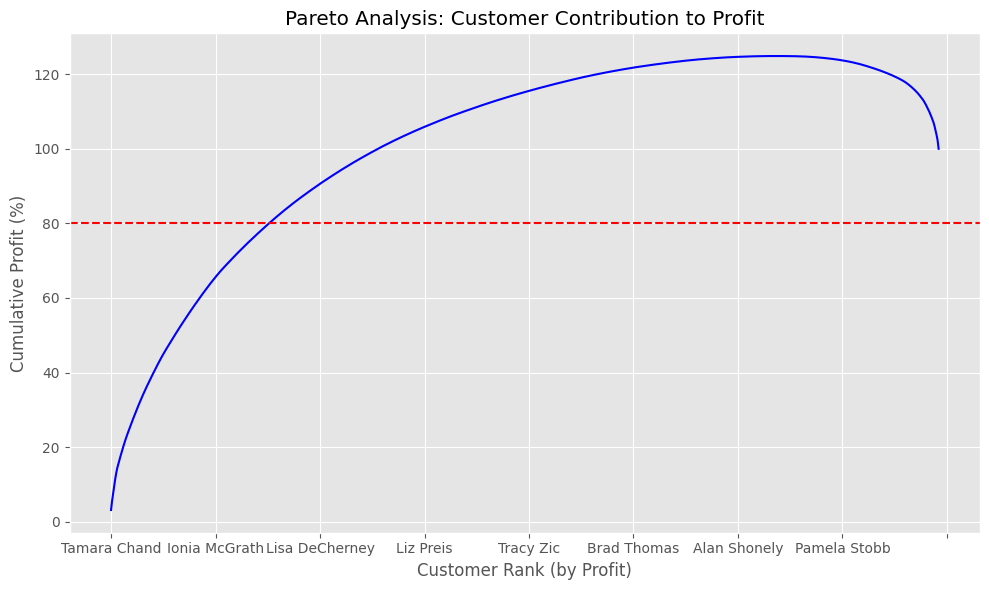


 152 out of 793 customers (~19.17%) contribute to 80% of the total profit.
 So Pareto Principle holds true in this case.


In [29]:
customer_profit = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False)

cumulative_profit = customer_profit.cumsum()
total_profit = customer_profit.sum()
cumulative_percent = 100 * cumulative_profit / total_profit

pareto_df = pd.DataFrame({
    'Profit': customer_profit,
    'Cumulative Profit %': cumulative_percent
})

plt.figure(figsize=(10, 6))
pareto_df['Cumulative Profit %'].plot(color='blue')
plt.axhline(80, color='red', linestyle='--')
plt.title('Pareto Analysis: Customer Contribution to Profit')
plt.xlabel('Customer Rank (by Profit)')
plt.ylabel('Cumulative Profit (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

top_customers_cutoff = cumulative_percent[cumulative_percent <= 80].count()
total_customers = len(customer_profit)
percent_customers = 100 * top_customers_cutoff / total_customers

print(f"\n {top_customers_cutoff} out of {total_customers} customers (~{percent_customers:.2f}%) contribute to 80% of the total profit.\n So Pareto Principle holds true in this case.")


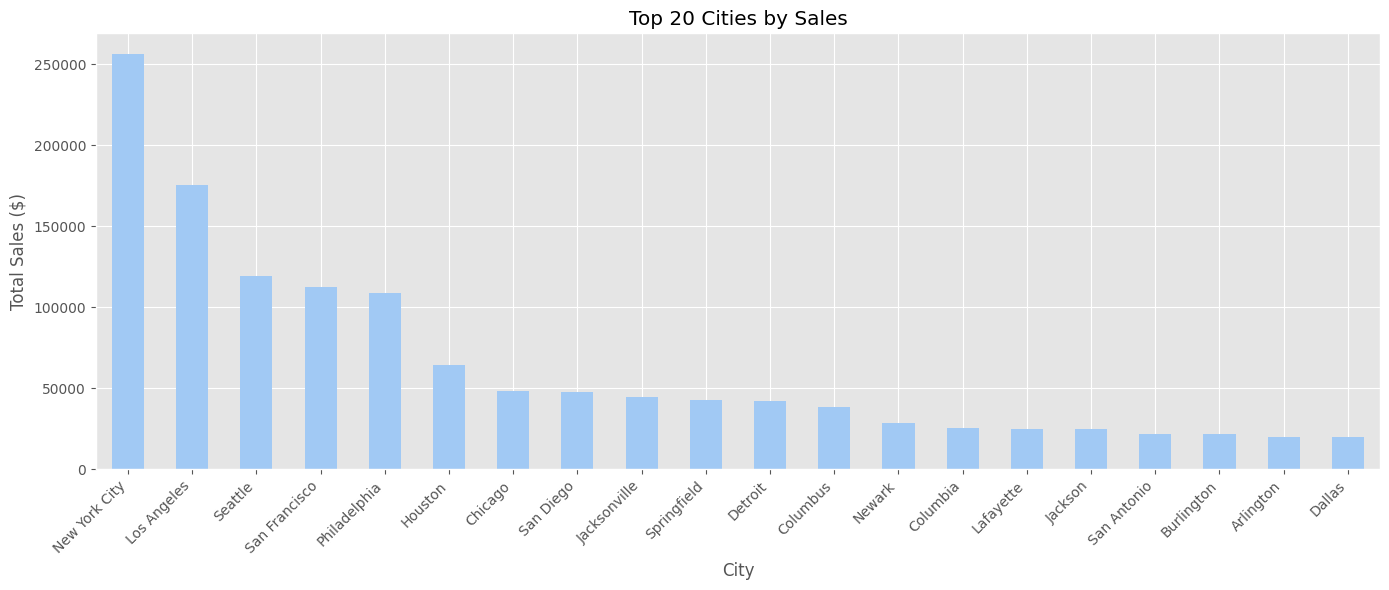

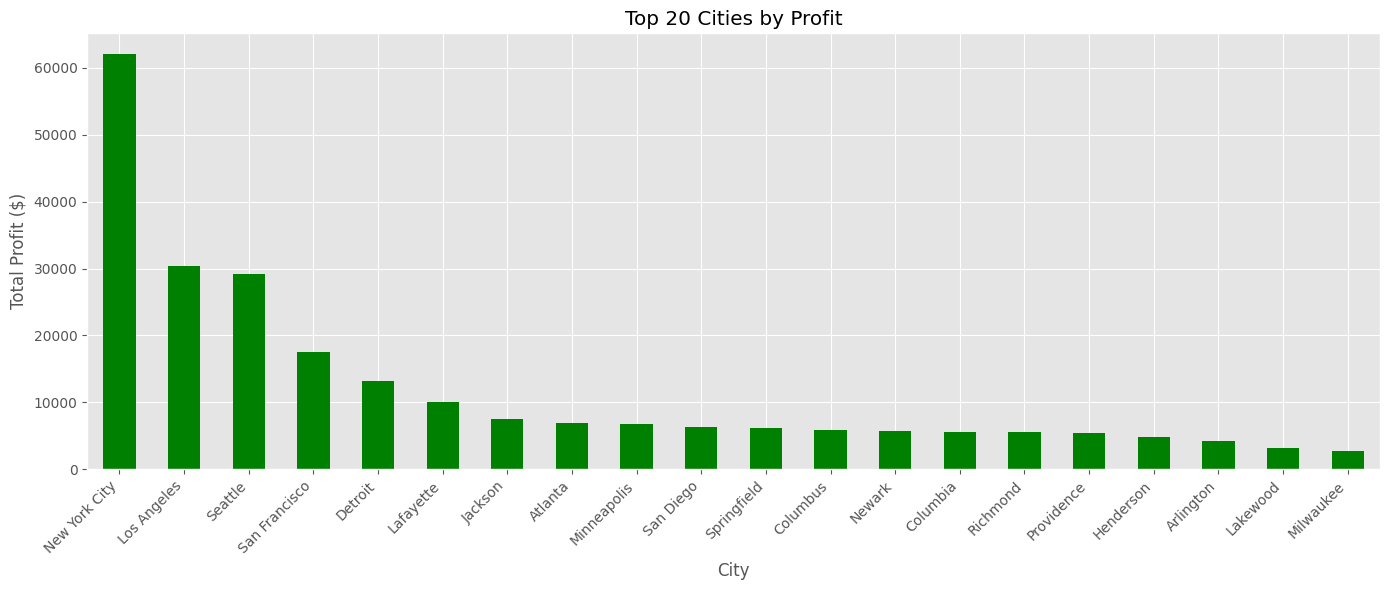

Top 20 Cities by Sales vs Profit:


,Top 20 Sales,Top 20 Profit
City,,
New York City,256368.1610,62036.9837
Los Angeles,175851.3410,30440.7579
Seattle,119540.7420,29156.0967
San Francisco,112669.0920,17507.3854
Philadelphia,109077.0130,NaN
Houston,64504.7604,NaN
Chicago,48539.5410,NaN
San Diego,47521.0290,6377.1960
Jacksonville,44713.1830,NaN


In [31]:
city_summary = df.groupby('City')[['Sales', 'Profit']].sum()

top_20_sales = city_summary.sort_values(by='Sales', ascending=False).head(20)

top_20_profit = city_summary.sort_values(by='Profit', ascending=False).head(20)

plt.figure(figsize=(14, 6))
top_20_sales['Sales'].plot(kind='bar')
plt.title('Top 20 Cities by Sales')
plt.ylabel('Total Sales ($)')
plt.xlabel('City')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
top_20_profit['Profit'].plot(kind='bar', color='green')
plt.title('Top 20 Cities by Profit')
plt.ylabel('Total Profit ($)')
plt.xlabel('City')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

top_20_combined = pd.concat([
    top_20_sales[['Sales']].rename(columns={'Sales': 'Top 20 Sales'}),
    top_20_profit[['Profit']].rename(columns={'Profit': 'Top 20 Profit'})
], axis=1)

print("Top 20 Cities by Sales vs Profit:")
top_20_combined


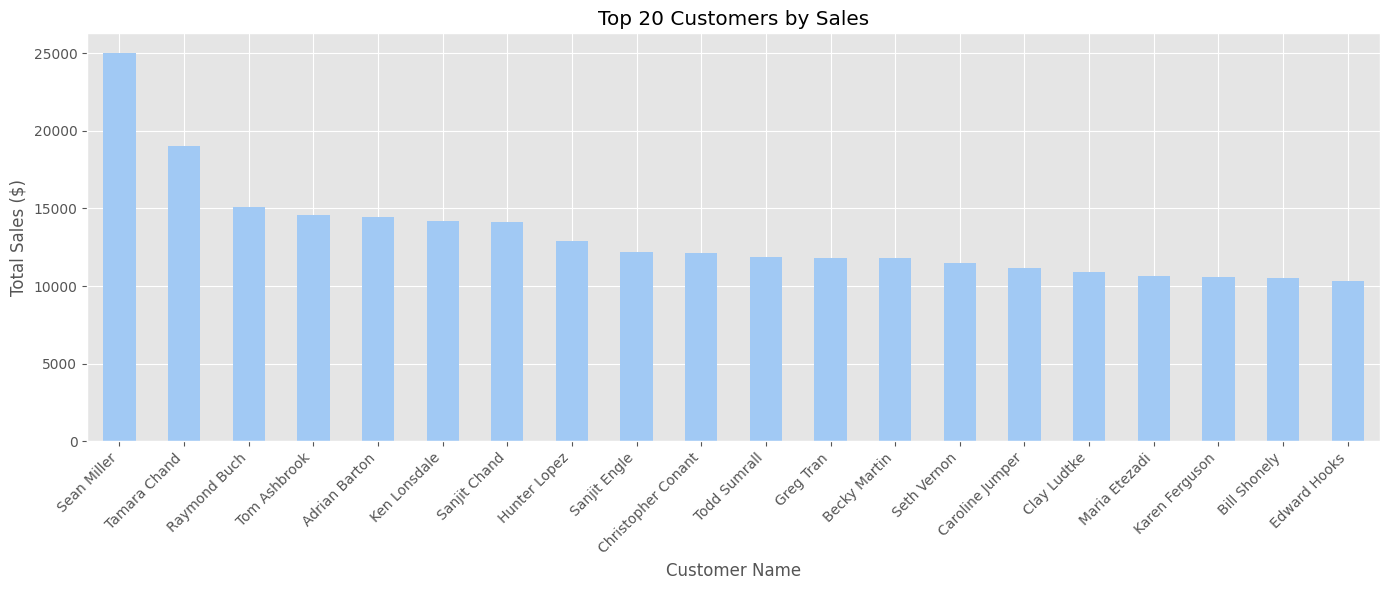

🧾 Top 20 Customers by Total Sales:

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Todd Sumrall          11891.751
Greg Tran             11820.120
Becky Martin          11789.630
Seth Vernon           11470.950
Caroline Jumper       11164.974
Clay Ludtke           10880.546
Maria Etezadi         10663.728
Karen Ferguson        10604.266
Bill Shonely          10501.653
Edward Hooks          10310.880
Name: Sales, dtype: float64


In [ ]:
top_customers_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 6))
top_customers_sales.plot(kind='bar')
plt.title('Top 20 Customers by Sales')
plt.ylabel('Total Sales ($)')
plt.xlabel('Customer Name')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 20 Customers by Total Sales:\n")
print(top_customers_sales)


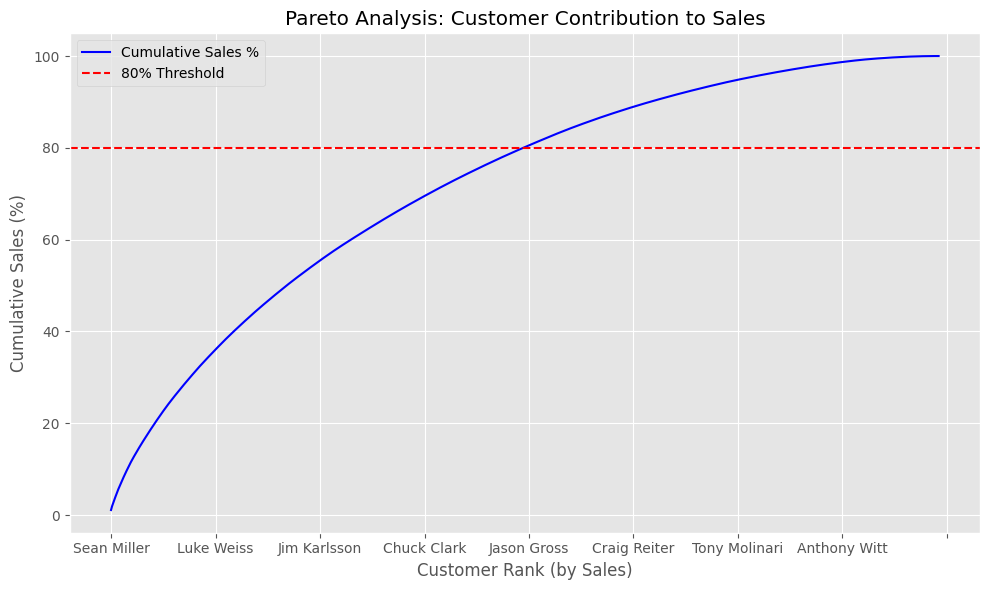


 395 out of 793 customers (~49.81%) contribute to 80% of the total sales. 
 So Pareto Principle does not holds true in this case


In [34]:
customer_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False)

cumulative_sales = customer_sales.cumsum()
total_sales = customer_sales.sum()
cumulative_sales_percent = 100 * cumulative_sales / total_sales

sales_pareto_df = pd.DataFrame({
    'Sales': customer_sales,
    'Cumulative Sales %': cumulative_sales_percent
})

plt.figure(figsize=(10, 6))
sales_pareto_df['Cumulative Sales %'].plot(color='blue')
plt.axhline(80, color='red', linestyle='--', label='80% Threshold')
plt.title('Pareto Analysis: Customer Contribution to Sales')
plt.xlabel('Customer Rank (by Sales)')
plt.ylabel('Cumulative Sales (%)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

top_customers_sales_cutoff = cumulative_sales_percent[cumulative_sales_percent <= 80].count()
total_customers = len(customer_sales)
percent_top_customers = 100 * top_customers_sales_cutoff / total_customers

print(f"\n {top_customers_sales_cutoff} out of {total_customers} customers (~{percent_top_customers:.2f}%) contribute to 80% of the total sales. \n So Pareto Principle does not holds true in this case")


****Marketing Strategy Recommendations:**

1. Prioritize States with High Sales and High Profit
New York and California stand out as the strongest performers in both sales and profit.

These states are ideal for continued investment, loyalty programs, and premium offerings.

Focus marketing resources here to reinforce customer loyalty and maintain a competitive edge.

2. Investigate High-Sales but Low-Profit States
States like Texas, Illinois, and Pennsylvania (including cities like Houston, Chicago, and Philadelphia) showed strong sales but did not appear in the top profit list.

These may suffer from high discounting, expensive shipping, or low-margin product mixes.

Suggested actions:

Review pricing and discount strategies

Adjust product offerings to improve margins

Target higher-margin customer segments

3. Explore High-Profit Emerging Cities
Cities like Atlanta, Minneapolis, and Lafayette had modest sales but made the top profit list.

These are opportunities for targeted expansion and scaled marketing efforts.

Test new offers, upsell campaigns, or location-specific advertising.

4. Customer Targeting Strategy
For profit, Pareto applies: ~20% of customers generate 80% of the profit.

These are your VIPs — reward them with personalized offers, early access to promotions, and referral incentives.

For sales, Pareto does not apply: nearly 50% of customers contribute to 80% of sales.

Maintain broad communication and engagement strategies

Focus on increasing order value and frequency across your full customer base

5. City-Specific Focus
Top performers in both Sales and Profit:

New York City

Los Angeles

Seattle

These cities should be at the top of your marketing priority list.

Consider:

Localized promotions

Regional influencers

Geo-targeted online ads

Watchlist Cities (High Sales, Low Profit):

Philadelphia, Houston, Chicago, Dallas

Reevaluate marketing spend in these areas and explore causes of low profitability.